In [1]:
import operator
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from IPython.display import Image, display

In [ ]:
class Pracstate(TypedDict):
    name : str
    age : str
    logs : Annotated[list[str], operator.add] 

In [3]:
def task_a(state: Pracstate):
    info = state["name"] + state["age"]
    return {"logs": [info]}

def task_b(state: Pracstate):
    return {"logs": ["Task B completed"]}

In [4]:
graph = StateGraph(Pracstate)

graph.add_node('task_a', task_a)
graph.add_node('task_b', task_b)

graph.add_edge(START, 'task_a')
graph.add_edge(START, 'task_b')

graph.add_edge('task_a', END)
graph.add_edge('task_b', END)

In [5]:
app = graph.compile()

result = app.invoke({"name": "Alice", "age": "28", "logs": []})
print(result["logs"])

['Alice28', 'Task B completed']


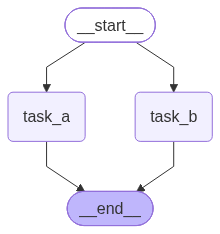

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))